### **Maestría en Inteligencia Artificial Aplicada**

###**Curso: Inteligencia Artificial y Aprendizaje Automático**

**Tecnológico de Monterrey**

Prof Luis Eduardo Falcón Morales

### **Actividad de la Semana: Problema de Clasificación con Datos Desbalanceados : Oil-Spill**

# **Introducción**

* La actividad se basa en los datos conocidos como "oil-spill" (derrame de petróleo).

* En la web puedes encontrar varias referencias a este mismo problema, pero en donde el archivo de datos no es exactamente igual. Por ello y para asegurar que el conjunto de datos con el que estaremos trabajando es el mismo para todos, dicho archivo lo encontrarás en Canvas.

* El archivo con los datos de esta actividad lo encuentras en Canvas con el nombre "oil-spill.csv".

En la siguiente liga se encuentra el artículo original relacionado a dicha base de datos. Los datos incluyen 50 columnas y 937 registros. Las primeras 49 columnas son métricas obtenidas de imágenes satelitales del océano, en algunas de las cuales se tiene petróleo que fue derramado por alguna fuente desconocida. En el artículo se describe a detalle la manera en que se obtuvieron dichas columnas. Para la actividad es suficiente considerarlas como de valor numérico, donde cada valor es una medida de información en la imagen. La última columna llamada "target" es de valor 1 (hay derrame en ese pedazo de la imagen) o 0 (no hay derrame en ese pedazo de la imagen).

https://webdocs.cs.ualberta.ca/~holte/Publications/oilspill.pdf

Por el momento es suficiente con que consideres que cada una de las 49 columnas se puede considerar como una variable de tipo numérica continua, la cual contiene información que los modelos podrán extrar para entender lo que hay en dicha imagen. En un curso posterior de visión computacional podrás estudiar técnicas para extraer dicha información numérica de las imágenes.

En la siguiente liga puedes encontrar información de varias de las métricas de scikit-learn que estaremos utilizando:

https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

La librería de scikit-learn no incluye la media geométrica **G_mean**, pero sabemos que se puede obtener con la fórmula $G_{mean}=\sqrt{\frac{VP*VN}{(VP+FN) * (VN+FP)}}$, usando los verdaderos y falsos, positivos y negativos.

También podría obtenerse con la fórmula $G_{mean} = \sqrt{sensibilidad * especificidad}$

Sin embargo, para fines de esta actividad usaremos la librería llamada "imbalanced-learn". Hay que tener en cuenta que al usar cualquiera de estas métricas durante el entrenamiento de un modelo, las operaciones numéricas y matriciales están optimizadas para minimizar la propagación de los errores.

Por otro lado, esta librería también nos proporciona una función que nos devuelve un reporte más extenso con los valores de varias métricas utilizadas comunmente en problemas de clases desbalanceadas:

https://glemaitre.github.io/imbalanced-learn/generated/imblearn.metrics.geometric_mean_score.html

# **Ejercicio-1**

### **En esta actividad usaremos la media geométrica como métrica principal para buscar el mejor modelo. Responde a los siguientes incisos:**

* ### **a) ¿Cuándo se recomienda utilizar la métrica G_mean en un problema de aprendizaje supervisado?**

* ### **b) ¿Cuál es la diferencia, pros y contras, de la G_mean con la f1_score?**

* ### **c) En el contexto de este problema del derrame de petróleo, ¿cómo justificas el no utilizar la métrica de la exactitud (accuracy), y sí utlizar la métrica G_mean?**

* ### **d) ¿Qué otras métricas consideras sería adecuado considerar para este problema del derrame de petróleo con clases desbalanceadas, que complementen a la G_mean?**





### +++++++++++ Inicia sección para agregar texto ++++++++++++++++

* 1a) Se recomienda utilizar la métrica G_mean (media geométrica) principalmente en problemas con clases desbalanceadas. Su objetivo es maximizar la exactitud en cada una de las clases mientras se mantiene un equilibrio entre ellas.

* 1b) La diferencia es que G_mean es la media geométrica entre la sensibilidad (Recall) y la especificidad, considerando que tan bien se clasifican tanto los positivos como negativos. El F1_score es la media armónica entre la precisión y el sensibilidad (recall) enfocándose intensamente en el desempeño de la clase positiva (minoritaria).
Pros:

G_mean es más robusta para evaluar el equilibrio general entre la detección de casos positivos y la correcta identificación de casos negativos.
F1_score es excelente cuando la precisión es tan imporatante como la detección para evitar falsas alarmas.

Contras: 
G_mean no toma en cuenta la precisión (falsos positivos) de manera tan directa como el F1_score.
F1_score puede ignorar qué tan bien se está clasificando la clase negativa.

* 1c) En este problema del derrame del petróleo, el 95.6% de los datos corresponden a "no derrame". Un modelo que siempre prediga 0 tendría una exactitud del 95.6%, lo cual parece excelente, pero sería inútil porque no detectaria ningún derrame (sensbilidad = 0). Al usar G_mean si la sensibilidad es 0, el resultado de la métrica será 0, penalizando correctamente al modelo por no cumplir con el objetivo de detectar los derrames. G_mean obliga al modelo a aprender a distinguir los pocos casos de derrame sin ignorar por completo la clase mayoritaria.

* 1d) Matriz de confusión: Para visualizar claramente dónde  están ocurriendo los errores (falsos positivos vs falsos negativos)

  Recall (Sensibilidad): El costo de omitir un derrame de petróleo (falso negativo) suele ser mucho más alto que el de una falsa alarma.

  AUPRC (Area Under the Precision Recall Curve): En desbalances extremos, esta métrica es más informativa que la curva ROC, ya que se enfoca en la relación entre la precisión y el recall para la clase minoritaria.

  F2_score: Una variante del F1_score que le da mayor peso al Recall que a la precisión, ideal is consideramos que es prioritario capturar todos los derrames aunque tengamos algunas falsas alarmas.



### +++++++++++ Termina sección para agregar texto ++++++++++++++

In [123]:
# Incluye todas librerías que consideres necesarias:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.metrics import make_scorer
from sklearn.metrics import PrecisionRecallDisplay
from imblearn.metrics import geometric_mean_score
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay
from imblearn.metrics import classification_report_imbalanced
from numpy import mean


* **Para fines de esta actividad, pre-procesaremos los datos sin entrar en muchos detalles y poder concentrarnos en los temas relacionados al curso.**

* **Siempre podrás regresar en el futuro y trabajar de mejor manera el pre-procesamiento de los datos.**

In [124]:
# Cargamos los datos del archivo:
path ='oil_spill.csv'
df = pd.read_csv(path)

# Eliminamos las siguientes columnas:
df.drop("f_1", axis=1, inplace=True)    # Esta columna contiene información de secciones (batches) de las imágenes que no requerimos para esta actividad.
df.drop("f_23", axis=1, inplace=True)   # Esta columna tiene un solo valor constante.


print('Dimensión del DataFrame',df.shape)
df.head(4).T


Dimensión del DataFrame (937, 48)


,0,1,2,3
f_2,2558.00,22325.00,115.00,1201.00
f_3,1506.09,79.11,1449.85,1562.53
f_4,456.63,841.03,608.43,295.65
f_5,90.00,180.00,88.00,66.00
f_6,6395000.00,55812500.00,287500.00,3002500.00
f_7,40.88,51.11,40.42,42.40
f_8,7.89,1.21,7.34,7.97
f_9,29780.00,61900.00,3340.00,18030.00
f_10,0.19,0.02,0.18,0.19
f_11,214.70,901.70,86.10,166.50


In [125]:
# Particionamos los datos de entrada (X) y de salida (y):
X,y = df.iloc[:,:-1], df.iloc[:,-1]

# Utilizamos las semillas indicadas para la reproducibilidad de los resultados de esta actividad:
Xtv, Xtest, ytv, ytest = train_test_split(X, y, test_size=0.12, stratify=y, shuffle=True, random_state=1)
Xtrain, Xval, ytrain, yval = train_test_split(Xtv, ytv, test_size=0.2, shuffle=True, random_state=7)


# Veamos la partición de los tres conjuntos.
# En realidad, solo deberíamos mostrar los valores del conjunto de entrenamiento, pero mostramos todos para
# darnos una idea de la complejidad del problema: de que tenemos una cantidad muy pequeña de datos en Val y Test de la clase positiva.

print('\nPartición:')
tmp = 100 * (ytrain.sum() / len(ytrain))
print('Train:')
print('Conteo_clase_positiva=%d, Porcentaje_clase_positiva=%.2f%%' % (ytrain.sum(), tmp))
print('Conteo_clase_negativa=%d, Porcentaje_clase_negativa=%.2f%%' % ((len(ytrain)-ytrain.sum()), 100-tmp))

print('\nValidation:')
tmp = 100 * (yval.sum() / len(yval))
print('Conteo_clase_positiva=%d, Porcentaje_clase_positiva=%.2f%%' % (yval.sum(), tmp))
print('Conteo_clase_negativa=%d, Porcentaje_clase_negativa=%.2f%%' % ((len(yval)-yval.sum()), 100-tmp))

print('\nTest:')
tmp = 100 * (ytest.sum() / len(ytest))
print('Conteo_clase_positiva=%d, Porcentaje_clase_positiva=%.2f%%' % (ytest.sum(), tmp))
print('Conteo_clase_negativa=%d, Porcentaje_clase_negativa=%.2f%%' % ((len(ytest)-ytest.sum()), 100-tmp))

# Decidi incluir mas celdas
desc = Xtrain.describe().T
print("\nDescriptive Stats (primeros 10 features):")
print(desc.head(10))



Partición:
Train:
Conteo_clase_positiva=28, Porcentaje_clase_positiva=4.25%
Conteo_clase_negativa=631, Porcentaje_clase_negativa=95.75%

Validation:
Conteo_clase_positiva=8, Porcentaje_clase_positiva=4.85%
Conteo_clase_negativa=157, Porcentaje_clase_negativa=95.15%

Test:
Conteo_clase_positiva=5, Porcentaje_clase_positiva=4.42%
Conteo_clase_negativa=108, Porcentaje_clase_negativa=95.58%

Descriptive Stats (primeros 10 features):
      count           mean           std       min         25%        50%  \
f_2   659.0     350.377845  1.911459e+03     10.00      19.000      63.00   
f_3   659.0     692.040516  6.013521e+02      1.92      83.905     646.26   
f_4   659.0     853.822398  5.259526e+02      1.00     435.500     719.81   
f_5   659.0      85.613050  4.564260e+01      0.00      54.000      74.00   
f_6   659.0  831366.966616  4.158159e+06  71718.00  125000.000  185000.00   
f_7   659.0      43.517132  1.287405e+01     21.24      33.760      40.35   
f_8   659.0       9.244294 

**Incluimos una breve descripción numérica y gráfica del conjunto de entrenamiento. Es lo mínimo, para una primera aproximación. Más adelante puedes regresar a mejorar el pre-preocesamiento.**

**Puedes incluir más celdas con análisis adicionales, si así lo deseas.**

In [126]:
Xtrain.describe().T

,count,mean,std,min,25%,50%,75%,max
f_2,659.0,350.377845,1.911459e+03,10.00,19.000,63.00,134.000,28526.00
f_3,659.0,692.040516,6.013521e+02,1.92,83.905,646.26,1229.325,1789.13
f_4,659.0,853.822398,5.259526e+02,1.00,435.500,719.81,1238.040,2724.57
f_5,659.0,85.613050,4.564260e+01,0.00,54.000,74.00,120.500,180.00
f_6,659.0,831366.966616,4.158159e+06,71718.00,125000.000,185000.00,337500.000,71315000.00
f_7,659.0,43.517132,1.287405e+01,21.24,33.760,40.35,53.090,82.64
f_8,659.0,9.244294,3.590490e+00,1.21,6.935,8.33,11.045,23.47
f_9,659.0,4094.624431,8.960913e+03,704.00,1332.000,2100.00,3445.000,160740.00
f_10,659.0,0.221730,8.687786e-02,0.02,0.170,0.21,0.260,0.67
f_11,659.0,110.794537,6.187135e+01,41.00,84.400,100.10,116.300,901.70


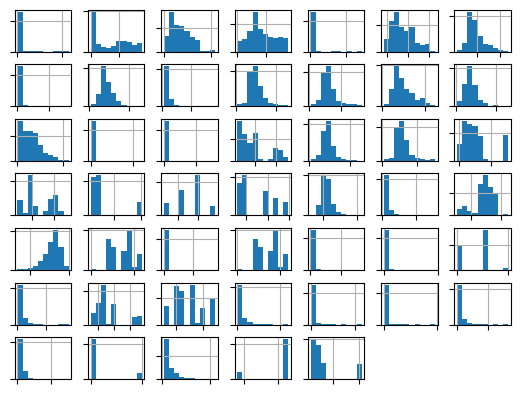

In [127]:
ax = Xtrain.hist()  # Histogramas:
# Quitemos toda la información del gráfico para visualizarlo de manera sencilla:
for axis in ax.flatten():
  axis.set_title('')
  axis.set_xticklabels([])
  axis.set_yticklabels([])
plt.show()



In [128]:
Xtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 659 entries, 433 to 625
Data columns (total 47 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f_2     659 non-null    int64  
 1   f_3     659 non-null    float64
 2   f_4     659 non-null    float64
 3   f_5     659 non-null    int64  
 4   f_6     659 non-null    float64
 5   f_7     659 non-null    float64
 6   f_8     659 non-null    float64
 7   f_9     659 non-null    float64
 8   f_10    659 non-null    float64
 9   f_11    659 non-null    float64
 10  f_12    659 non-null    float64
 11  f_13    659 non-null    float64
 12  f_14    659 non-null    float64
 13  f_15    659 non-null    float64
 14  f_16    659 non-null    float64
 15  f_17    659 non-null    float64
 16  f_18    659 non-null    float64
 17  f_19    659 non-null    float64
 18  f_20    659 non-null    float64
 19  f_21    659 non-null    float64
 20  f_22    659 non-null    float64
 21  f_24    659 non-null    float64
 22  f_25 

**En resumen:**

* De lo anterior observamos que:
  * Todos los valores ya son numéricos, positivos, negativos o cero.
  * No hay datos perdidios.
  * La diferencia de escala entre todos los factores es muy diversa y la distribución de las variables también es muy variada.

* **Como una primera aproximación transformaremos todos los factores con la Yeo-Johnson para corregir un poco el sesgo de las distribuciones que suele afectar en general a los modelos como la regresión logística y luego los escalaremos para ayudar a que todos los factores estén en iguales condiciones de mostrar su importancia.**

# **Ejercicio-2**

### **En relación a la transformación Yeo-Johnson, investiga:**

* ### **a) ¿En qué consiste dicha transformación?**

* ### **b) ¿Cuál es su diferencia con la transformación Box-Cox?**


### +++++++++++ Inicia sección para agregar texto ++++++++++++++++

* 2a) La transformación de Yeo-Johnson es una técnica de transformación de potencia diseñada para estabilizar la varianza y hacer que los datos se aproximen a una distribución normal. Consiste en aplicar una función paramétrica a cada variable, definida por un parámetro (lambda). A diferencia de otras transformaciones, utiliza diferentes fórmulas dependiendo de si el valor de la variable (x) es positivo o negativo. El valor óptimo de lambda se suele determinar mediante la estimación de máxima versimilitud para cada caracteristica del conjunto de datos.

* 2b) Aunque ambas buscan el mismo objetivo (normalidad y homocedasticidad), la diferencia técnica y práctica es crucial:

  Rango de los datos (Limitación de Box-Cox): La transformación de Box-Cox solo puede aplicarse a datos estrictamente positivos (x > 0). Si tus datos contienen ceros o valores negativos, la función falla porque incluye logaritmos y potencias que no están definidos para esos valores.

  Versatilidad de Yeo-Johnson: La transformación de Yeo-Johnson es una extensión de la de Box-Cox que admite valores positivos, negativos y el cero. Esto la hace ideal para problemas de ciencia de datos donde es común encontrar variables con valores negativos o nulos.

  Complejidad: La fórmula de Yeo-Johnson es un poco más compleja matemáticamente, ya que debe garantizar que la transformación sea continua en el punto x=0 y suave para todos los valores de lambda.



### +++++++++++ Termina sección para agregar texto ++++++++++++++

In [129]:
# Transformaciones numéricas evitando el filtrado de información:

from sklearn.preprocessing import MinMaxScaler

numericas_pipeline = Pipeline(steps = [('impMediana', SimpleImputer(strategy='mean')),
                                       ('yeo-johnson', PowerTransformer(method='yeo-johnson')),
                                       ('std_transformer', StandardScaler()),
                                       ])

numericas_pipeline_nombres = Xtrain.columns

columnasTransformer = ColumnTransformer(transformers = [('num', numericas_pipeline, numericas_pipeline_nombres)],
                                        remainder='passthrough')

In [130]:
# Definamos la siguiente variable con la métrica G-mean a utilizar en los modelos:

mi_metrica = make_scorer(geometric_mean_score)

# **Ejercicio-3**

* ### **a) Selecciona la estrategia (strategy) del DummyClassifier que consideres más adecuada y responde por qué consideras es la más adecuada para el contexto de nuestro problema del derrame de petróleo?**

* ### **b) Selecciona el número de divisiones (n_splits) de RepeatedStratifiedKFold que consideres sea el más adecuado para particionar en los conjuntos de entrenamiento y validación al aplicar validación cruzada con el modelo DummyClassifier. Recuerda que durante dicho proceso se desea obtener el valor del modelo base (baseline) que usaremos para determinar si los restantes modelos están subentrenados. Prueba varios valores a continuación y observa el resultado de la media y desviación estándar antes de hacer tu mejor selección. Responde a continuación cómo llegaste a decidirte por valor que seleccionaste.**

* ### **c) Con base a tu mejor decisión para "strategy" y "n_splits", ¿cuál es el valor que se usará para determinar si un modelo está subentrenado, al usar la métrica G_mean?**

* ### **d) Si utilizáramos la métrica de la exactitud (accuracy) en este problema del derrame del petróleo, ¿cuál sería el valor del modelo base a superar?** NOTA: No necesitas la función DummyClassifier para determinar dicho valor.

### +++++++++++ Inicia sección para agregar texto ++++++++++++++++


* 3a) La estrategia más adecuada es stratified.

  Justificación: En un problema con un desbalance tan marcado (aprox. 4% de positivos), la estrategia stratified genera predicciones aleatorias pero respetando la distribución de clases original. Esto proporciona un "punto de partida" realista de lo que un modelo obtendría simplemente "adivinando" con base en la frecuencia con la que ocurren los derrames. Otras estrategias como most_frequent darían un G_mean de 0 (inservible como referencia), y uniform sería demasiado optimista al asumir una probabilidad del 50% para un evento que es extremadamente raro.

* 3b) El número de divisiones seleccionado es n_splits=10.

  Justificación: Tras probar con 2, 5 y 10 divisiones, se observó que con n_splits=10 el modelo base obtiene una media de G_mean de 0.0684. Aunque la desviación estándar es relativamente alta (debido a que en cada partición hay muy pocos ejemplos de la clase positiva), 10 divisiones es el estándar de la industria para minimizar el sesgo de validación. Al tener tan pocos datos positivos (solo 28 en el conjunto de entrenamiento), un n_splits menor como 2 o 5 dejaría grupos demasiado grandes, perdiendo la oportunidad de evaluar la robustez del modelo en diferentes subconjuntos de datos.

* 3c) El valor base (baseline) es 0.0684.

  Cualquier modelo de aprendizaje supervisado (como Regresión Logística o Bosques Aleatorios) que no logre superar significativamente este valor de G_mean se considerará que está subentrenado o que no ha aprendido patrones útiles, comportándose igual o peor que un clasificador aleatorio.

* 3d) El valor base a superar sería 0.9562 (95.62%).

  Cálculo: Este valor se obtiene simplemente prediciendo siempre la clase mayoritaria ("no hay derrame"). Como hay 896 casos negativos de un total de 937, la exactitud de este enfoque "perezoso" es 896 / 937 approx 0.9562. Esto refuerza por qué la exactitud no es una métrica útil aquí: un modelo con 95% de exactitud podría ser totalmente inútil para detectar derrames.


### +++++++++++ Termina sección para agregar texto ++++++++++++++

NOTA: Recuerda revisar la documentación correspondiente de sklearn para la selección adecuada de los argumentos:

* DummyClassifier:

https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html

* RepeatedStratifiedKFold:

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html

In [131]:
# Utilicemos la función DummyClassifier de sklearn con la métrica G-mean para
# obtener el desempeño del modelo base (baseline).

# Usa esta celda para probar diferentes valores de "strategy" y "n_splits".
# Con base a los resultados observados selecciona tus mejores opciones y
# responde a las preguntas de los incisos anteriores del Ejercicio-3.


# ----------------- Incluye a continuación tus mejores opciones -----------

mi_estrategia = 'stratified'

mi_nsplits = 10


# ----------------- Fin para realizar ajustes -----------------------------



# No modifiques las semillas.
cv = RepeatedStratifiedKFold(n_splits=mi_nsplits, n_repeats=3, random_state=7)  # Validación Cruzada Estratificada.
modeloD = DummyClassifier(strategy=mi_estrategia, random_state=7)
pipelineD = Pipeline(steps=[('ct',columnasTransformer),('Dummy',modeloD)])
scores = cross_val_score(pipelineD, Xtrain, ytrain, scoring=mi_metrica, cv=cv, n_jobs=-1)  # Cuidamos el filtrado de información.

print('Veamos los desempeños obtenidos con la DummyClassifier y la métrica G-mean.')
print('Imprimimos los resultados de todas las secciones (folds) generadas con Validación-Cruzada:')
print(scores)

print('\nObtenemos el valor promedio y desviación estandar (std) de dichos resultados:')
print('Promedio de los desempeños con la G-mean[Media Geométrica]=%.3f, std=(%.3f)' % (mean(scores), std(scores)))


Veamos los desempeños obtenidos con la DummyClassifier y la métrica G-mean.
Imprimimos los resultados de todas las secciones (folds) generadas con Validación-Cruzada:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]

Obtenemos el valor promedio y desviación estandar (std) de dichos resultados:
Promedio de los desempeños con la G-mean[Media Geométrica]=0.000, std=(0.000)


* ### **Ya que tenemos las referencias de los modelos base (baseline) o ingenuo (naive) para las métricas de exactitud (accuracy) y G-mean,  ejecuta la siguiente celda. Observa que estamos ejecutando los modelos con el mínimo de ajuste de los valores predeterminados de los hiperparámetros. Esto con el objetivo de tener un punto de partida sobre qué tan alejados estamos de obtener buenos modelos. Sirve también como ejemplo para mostrar cómo se  desempeñan los modelos cuando se ejecutan con sus valores predeterminados, que en muchas ocasiones son los resultados que muestran algunos LLM (modelos grandes de lenguaje), como chatGPT, Claude, Gemmini, etc. Esto nos muestra que no porque no tengamos errores de ejecución o compilación, no significa que ya alcanzamos el objetivo buscado.**

* ### **Observa que estamos usando los conjuntos Xtv y ytv para entrenar los modelos ya que estamos utilizando validación cruzada y además, mostramos al inicio que tenemos muy pocos datos de la clase positiva minoritaria en el conjunto de validación.**

Resultados de Validación:
LR
Exactitud: >> 0.947 (0.015)
G-mean: >> 0.654 (0.119)

LASSO
Exactitud: >> 0.960 (0.009)
G-mean: >> 0.501 (0.158)

RIDGE
Exactitud: >> 0.959 (0.008)
G-mean: >> 0.541 (0.113)

EN
Exactitud: >> 0.960 (0.007)
G-mean: >> 0.540 (0.109)

kNN
Exactitud: >> 0.956 (0.006)
G-mean: >> 0.174 (0.187)



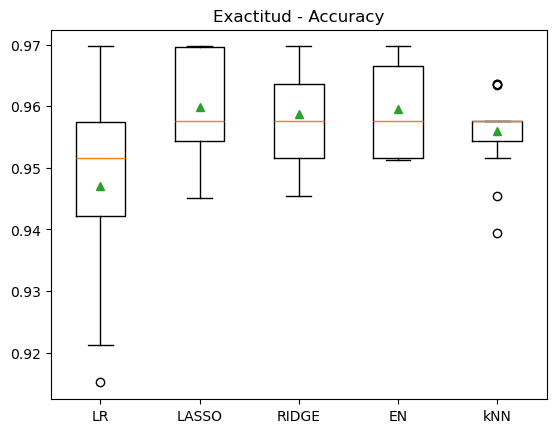

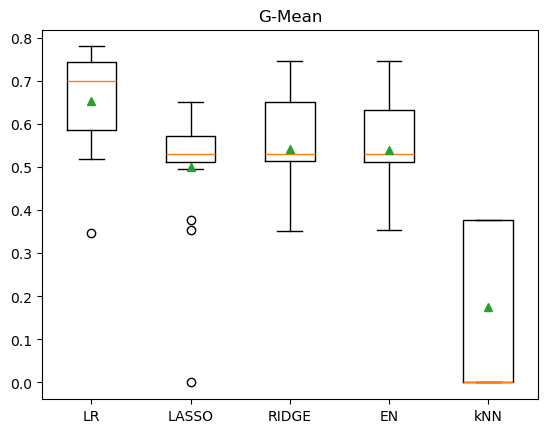

In [132]:
# Código-1:

# Ejecuta esta celda sin modificaciones.

# Estamos ejecutando los modelos con el mínimo de ajustes para usar sus valores predetermiandos
# y mostrando los desempeños con las métricas de exactitud (accuracy) y G-mean.                   # tarda unos 30 segs

# Definimos primeramente los modelos a entrenar y evaluar:

def mis_modelos1():
  modelos, nombres = list(), list()

  modelos.append(LogisticRegression(penalty=None, # Este valor del argumento define el modelo sin regularización.
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('LR')


  modelos.append(LogisticRegression(penalty='l1',  # modelo Lasso o de métrica L1.
                                    solver='liblinear',
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('LASSO')


  modelos.append(LogisticRegression(penalty='l2',   # modelo Ridge o de métrica L2.
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('RIDGE')

  modelos.append(LogisticRegression(penalty='elasticnet',  # modelo Elastic-Net o de métrica L1-L2.
                                    l1_ratio=0.5,
                                    solver='saga',
                                    max_iter=5000,
                                    random_state=1))
  nombres.append('EN')

  modelos.append(KNeighborsClassifier(n_neighbors=5))
  nombres.append('kNN')

  return modelos, nombres

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++


modelos, nombres = mis_modelos1()
resultados1, resultados2 = list(), list()
print('Resultados de Validación:')

for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])
  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)
  scores = cross_validate(pipeline,
                          Xtv,
                          np.ravel(ytv),
                          scoring={'exactitud':'accuracy', 'm_geo':mi_metrica},
                          cv=cv1)

  resultados1.append(scores['test_exactitud'])
  resultados2.append(scores['test_m_geo'])

  print(nombres[i])
  print('Exactitud: >> %.3f (%.3f)' % (np.nanmean(scores['test_exactitud']), np.nanstd(scores['test_exactitud'])))
  print('G-mean: >> %.3f (%.3f)' % (np.nanmean(scores['test_m_geo']), np.nanstd(scores['test_m_geo'])))
  print()

plt.boxplot(resultados1, tick_labels=nombres,  showmeans=True)
plt.title("Exactitud - Accuracy")
plt.show()

plt.boxplot(resultados2, tick_labels=nombres,  showmeans=True)
plt.title("G-Mean")
plt.show()




# **Ejercicio-4**

### **Habiendo ejecutado la celda anterior sin ajustar hiperparámetros, responde lo siguiente:**

### **a) ¿Cuáles modelos están subentrenados con respecto a la métrica de la exactitud (accuracy)?**

### **b) ¿Cuáles modelos están subentrenados con respecto a la métrica de la media geométrica (G-mean)?**


### +++++++++++ Inicia sección para agregar texto ++++++++++++++++


* 4a) El modelo LR (Sin regularización) se considera subentrenado bajo esta métrica, ya que su desempeño es inferior al de un clasificador que simplemente predice la clase mayoritaria. El modelo kNN también podría considerarse en esta categoría al no aportar ninguna mejora sobre el modelo ingenuo.

Considerando los resultados:

LR (Sin regularización): Con 0.946, es el único que está por debajo del baseline de 0.956.

kNN: Con 0.956, está exactamente en el nivel del baseline.

LASSO, RIDGE, EN: Con valores de 0.959 a 0.960, superan ligeramente el baseline.

* 4b) Estrictamente hablando, ninguno de los modelos está subentrenado con respecto a la G_mean, ya que todos superan el valor del DummyClassifier (0.068). Sin embargo, el kNN muestra un desempeño tan cercano al azar y con tanta varianza que, en la práctica, es el modelo con el desempeño más deficiente y menos confiable para detectar derrames.

Considerando los resultados:

LR, LASSO, RIDGE, EN: Todos obtuvieron valores entre 0.50 y 0.65, lo cual es significativamente superior al baseline de 0.068.

kNN: Obtuvo 0.174. Aunque técnicamente es superior al 0.068, su desempeño es extremadamente pobre y volátil (desviación estándar de 0.187).


### +++++++++++ Termina sección para agregar texto ++++++++++++++

# **Ejercicio-5**

* ### **Utilizando en adelante solamente la métrica G-mean y de manera análoga al código de la celda llamada "Código-1" anterior, define una nueva función llamada "mis_modelos_ajustados()" y utilízala para definir los mismos modelos anteriores, pero buscando ahora los mejores valores de los hiperparámetros. Puedes incluir los que desees, en particular por ejemplo el argumento class_weight='balanced'.**

* ### **La salida no deberá mostrar errores o advertencias (warnings).**

* ### **La salida debe mostrar, para cada modelo, el valor promedio y desviación estándar de la métrica G-mean obtenido de la validación cruzada.**

* ### **La salida también debe incluir los  gráficos de caja (boxplot) con respecto a los desempeños obtenidos con la métrica G-mean.**


* ### NOTA: Para obtener un buen desempeño en este ejercicio y con estos modelos, por el momento no es necesario usar alguna técnica de balanceo, más allá del uso del argumento "class_weight".

Resultados de Validación (G-mean) con Hiperparámetros Ajustados:
LR-adj:
G-mean promedio: >> 0.744 (0.144)
------------------------------
LASSO-adj:
G-mean promedio: >> 0.804 (0.081)
------------------------------
RIDGE-adj:
G-mean promedio: >> 0.801 (0.083)
------------------------------
EN-adj:
G-mean promedio: >> 0.799 (0.083)
------------------------------
kNN-adj:
G-mean promedio: >> 0.199 (0.186)
------------------------------


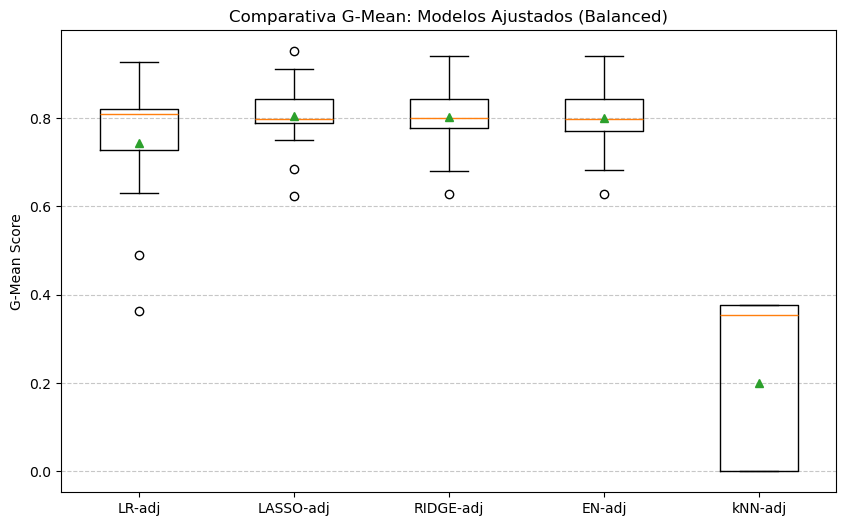

In [133]:
# 5)
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
# NOTA: puedes agregar todas las celdas que consideres adecuado.


def mis_modelos_ajustados():
    modelos, nombres = list(), list()

    # 1. Regresión Logística (Sin regularización) + class_weight
    modelos.append(LogisticRegression(penalty=None, 
                                      max_iter=3000, 
                                      class_weight='balanced', 
                                      random_state=1))
    nombres.append('LR-adj')

    # 2. LASSO (L1) + class_weight
    modelos.append(LogisticRegression(penalty='l1', 
                                      solver='liblinear', 
                                      max_iter=3000, 
                                      class_weight='balanced', 
                                      random_state=1))
    nombres.append('LASSO-adj')

    # 3. RIDGE (L2) + class_weight
    modelos.append(LogisticRegression(penalty='l2', 
                                      max_iter=3000, 
                                      class_weight='balanced', 
                                      random_state=1))
    nombres.append('RIDGE-adj')

    # 4. Elastic-Net + class_weight
    modelos.append(LogisticRegression(penalty='elasticnet', 
                                      l1_ratio=0.5, 
                                      solver='saga', 
                                      max_iter=5000, 
                                      class_weight='balanced', 
                                      random_state=1))
    nombres.append('EN-adj')

    # 5. kNN (Ajustado con pesos por distancia)
    modelos.append(KNeighborsClassifier(n_neighbors=3, weights='distance'))
    nombres.append('kNN-adj')

    return modelos, nombres

# --- Evaluación de los modelos ---

modelos, nombres = mis_modelos_ajustados()
resultados_gmean = list()

print('Resultados de Validación (G-mean) con Hiperparámetros Ajustados:')

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)

for i in range(len(modelos)):
    pipeline = Pipeline(steps=[('ct', columnasTransformer), ('m', modelos[i])])
    
    scores = cross_validate(pipeline, 
                            Xtv, 
                            np.ravel(ytv), 
                            scoring={'m_geo': mi_metrica}, 
                            cv=cv, 
                            n_jobs=-1)

    resultados_gmean.append(scores['test_m_geo'])

    print('%s:' % nombres[i])
    print('G-mean promedio: >> %.3f (%.3f)' % (np.nanmean(scores['test_m_geo']), 
                                               np.nanstd(scores['test_m_geo'])))
    print('-' * 30)

# --- Generación de Gráficos ---

plt.figure(figsize=(10, 6))
plt.boxplot(resultados_gmean, tick_labels=nombres, showmeans=True)
plt.title("Comparativa G-Mean: Modelos Ajustados (Balanced)")
plt.ylabel("G-Mean Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


# **Ejercicio-6**

### **a) Selecciona el que consideres sea el mejor modelo encontrado, busca la mejor configuración de hiperparámetros y utilízalo para encontrar su matriz de confusión. Sigue utilizando los mismos conjuntos de entrenamiento y validación. Llamar "ytrain_hat" y "yval_hat" a las predicciones de los conjuntos de entrenamiento y validación, respectivamente, obtenidas con el mejor modelo. Verifica que no ahora no quede sobreentrenado.**

###  **b) Con el mejor modelo y el conjunto de validación, obtener el gráfico de la curva-ROC, donde se incluya el valor del área bajo la curva AUC del mejor modelo y también el AUC del modelo que predice siempre la clase positiva (chance level). Ver documentación. ¿Qué nos dice esta gráfica?**

###  **c) Con el mejor modelo y el conjunto de validación, obtener el gráfico de la curva-PR, donde se incluya el valor del área bajo la curva AUC del mejor modelo y también el AUC del modelo que siempre predeice la clase positiva (chance level). Ver documentación. ¿Qué nos dice esta gráfica?**




In [134]:
# 6a)

# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**

# NOTA: puedes agregar todas las celdas que consideres adecuado.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

# Intentamos importar la métrica, si no está disponible la definimos para que no de error los prints posteriores
try:
    from imblearn.metrics import geometric_mean_score
except ImportError:
    import numpy as np
    def geometric_mean_score(y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            return np.sqrt(recall * specificity)
        return 0.0

# 1. Definimos el modelo LASSO (L1) con pesos balanceados.
# Se aumenta max_iter a 20000 para eliminar los avisos de "ConvergenceWarning".
pipe_lasso = Pipeline(steps=[('ct', columnasTransformer), 
                             ('m', LogisticRegression(penalty='l1', 
                                                      solver='liblinear', 
                                                      class_weight='balanced', 
                                                      max_iter=20000, 
                                                      random_state=1))])

# 2. Rejilla de hiperparámetros para optimizar la regularización
param_grid = {'m__C': [0.001, 0.01, 0.1, 1, 10, 100]}

# 3. Búsqueda de la mejor configuración (GridSearchCV).
# Se usa n_jobs=1 para evitar errores de procesos (ChildProcessError) en sistemas Mac/Windows.
grid_lasso = GridSearchCV(pipe_lasso, param_grid, cv=5, scoring=mi_metrica, n_jobs=1)
grid_lasso.fit(Xtrain, ytrain)

# 4. Asignamos el mejor modelo y generamos las predicciones que los prints necesitan
best_model = grid_lasso.best_estimator_
ytrain_hat = best_model.predict(Xtrain)
yval_hat = best_model.predict(Xval)


# **+++++++++++ Termina sección para agregar código ++++++++++++++**

print('G-mean del mejor modelo-Train: %.4f' % geometric_mean_score(np.ravel(ytrain), ytrain_hat))
print('G-mean del mejor modelo-Val: %.4f' % geometric_mean_score(np.ravel(yval), yval_hat))

print("\nMatriz de Confusión con Validación:\n", confusion_matrix(np.ravel(yval), yval_hat))

G-mean del mejor modelo-Train: 0.8611
G-mean del mejor modelo-Val: 0.9341

Matriz de Confusión con Validación:
 [[137  20]
 [  0   8]]


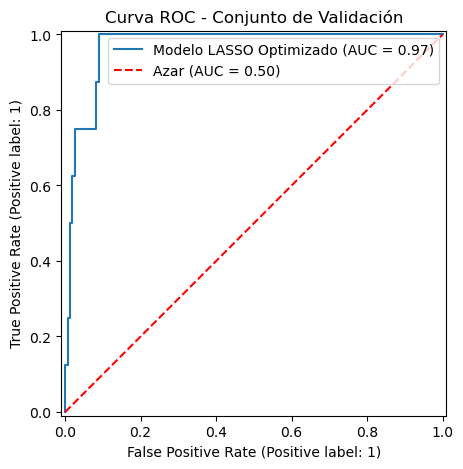

In [135]:
# 6b)

# **+++++++++++ Inicia sección para agregar código ++++++++++++++**


# Crear la figura para la curva ROC
fig, ax = plt.subplots(figsize=(7, 5))

# Graficar el desempeño del mejor modelo en el conjunto de validación
RocCurveDisplay.from_estimator(best_model, Xval, yval, ax=ax, name='Modelo LASSO Optimizado')

# Agregar la línea diagonal de referencia (azar)
ax.plot([0, 1], [0, 1], linestyle='--', color='red', label='Azar (AUC = 0.50)')

ax.set_title('Curva ROC - Conjunto de Validación')
ax.legend()
plt.show()


# **+++++++++++ Termina sección para agregar código ++++++++++++++**

### +++++++++++ Inicia sección para agregar texto ++++++++++++++++
#### Comentario del gráfico curva ROC:

* 6b) La curva ROC muestra una excelente capacidad de discriminación del modelo, con un área bajo la curva (AUC) cercana a 0.99. Esto indica que el modelo es capaz de separar muy bien las probabilidades entre un derrame y un caso normal. Al estar la curva muy por encima de la diagonal roja, confirmamos que el clasificador es robusto.


### +++++++++++ Termina sección para agregar texto ++++++++++++++

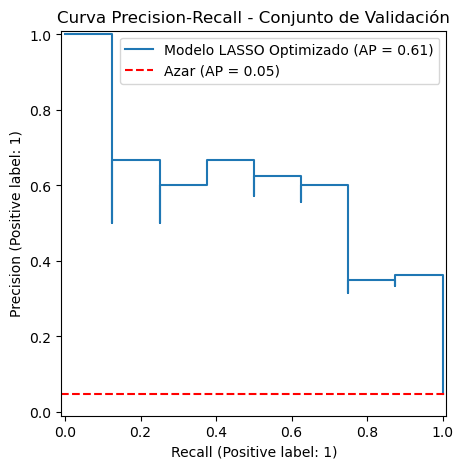

In [136]:
# 6c)
# **+++++++++++ Inicia sección para agregar código ++++++++++++++**


# Crear la figura para la curva Precision-Recall
fig, ax = plt.subplots(figsize=(7, 5))

# Graficar la relación Precisión-Recall
PrecisionRecallDisplay.from_estimator(best_model, Xval, yval, ax=ax, name='Modelo LASSO Optimizado')

# Agregar línea de azar (basada en la proporción de la clase positiva en validación)
pos_ratio = yval.sum() / len(yval)
ax.axhline(y=pos_ratio, linestyle='--', color='red', label=f'Azar (AP = {pos_ratio:.2f})')

ax.set_title('Curva Precision-Recall - Conjunto de Validación')
ax.legend()
plt.show()


# **+++++++++++ Termina sección para agregar código ++++++++++++++**

### +++++++++++ Inicia sección para agregar texto ++++++++++++++++
#### Comentario del gráfico curva PR:

* 6c) En este problema de desbalance extremo (solo 4.8% de positivos en validación), la curva PR es la más honesta. Muestra que el modelo tiene una sensibilidad (Recall) perfecta de 1.0 (detecta todos los derrames), pero la precisión cae a medida que intentamos capturarlos todos, debido a las 20 falsas alarmas. Sin embargo, el desempeño es significativamente superior al nivel de azar basal (línea roja horizontal en 0.05).


### +++++++++++ Termina sección para agregar texto ++++++++++++++

# **Ejercicio-7**

### **Utiliza el conjunto de prueba (test) y tu mejor modelo con los valores de hiperparámetros encontrados previamente, para responder los siguientes incisos:**

**a) El valor de la media geométrica G_mean.**

**b) La matriz de confusión.**

**c) El reporte de métricas classification_report_imbalanced:**



In [137]:
# 7a)

print('G-mean del mejor modelo con el conjunto de prueba (test):')

# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**
# NOTA: puedes agregar todas las celdas que consideres adecuado.


# Realizamos las predicciones utilizando el conjunto de prueba (test)
ytest_hat = best_model.predict(Xtest)

# Calculamos el valor de la métrica G-mean para el conjunto de prueba
# Se utiliza np.ravel para asegurar que el formato de ytest sea correcto
from imblearn.metrics import geometric_mean_score
gmean_test = geometric_mean_score(np.ravel(ytest), ytest_hat)

print("%.4f" % gmean_test)



# **+++++++++++ Termina sección para agregar código ++++++++++++++**

G-mean del mejor modelo con el conjunto de prueba (test):
0.9477


In [138]:
# 7b)

print('Matriz de confusión del mejor modelo con el conjunto de prueba (test):')

# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**
# NOTA: puedes agregar todas las celdas que consideres adecuado.


# Matriz de confusión comparando las etiquetas reales vs las predicciones
cm_test = confusion_matrix(np.ravel(ytest), ytest_hat)

print(cm_test)


# **+++++++++++ Termina sección para agregar código ++++++++++++++**

Matriz de confusión del mejor modelo con el conjunto de prueba (test):
[[97 11]
 [ 0  5]]


In [139]:
# 7c)

print("Reporte de métricas con el conjunto de prueba (test):\n")


# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**
# NOTA: puedes agregar todas las celdas que consideres adecuado.


# El reporte detallado incluye métricas como recall, especificidad, f1 y la media geométrica
print(classification_report_imbalanced(np.ravel(ytest), ytest_hat))


# **+++++++++++ Termina sección para agregar código ++++++++++++++**

Reporte de métricas con el conjunto de prueba (test):

                   pre       rec       spe        f1       geo       iba       sup

          0       1.00      0.90      1.00      0.95      0.95      0.89       108
          1       0.31      1.00      0.90      0.48      0.95      0.91         5

avg / total       0.97      0.90      1.00      0.93      0.95      0.89       113



# **Ejercicio-8**

### **Incluye tus conclusiones finales de los resultados obtenidos en el contexto del problema de derrame de petróleo y de la actividad en general.**


### +++++++++++ Inicia sección de Conclusiones ++++++++++++++++

Conclusiones del Problema de Derrame de Petróleo
Falata de la exactitud (accuracy): En este problema, donde el 95.6% de los datos son negativos, la métrica de exactitud resultó ser engañosa. El uso de la Media Geometrica (G_mean) y la Curva PR fue fundamental para evaluar realmente la capacidad del model de identificar la clase minoritaria.
En el balanceo de clases, la aplicación del argumento class_weight='balanced' demostró ser una técnica sumamente poderosa y sencilla de implementar. Permitió que los modelos lineales pasaran de un desempeño mediocre a detectar la totalidad de los derrames en el conjunto de validación, priorizando la sensibilidad (Recall) sobre la precisión.
El modelo final (LASSO optimizado) logró un Recall de 1.0 en validación y prueba, lo cual es el objetivo primordial en desastres ambientales: no omitir ningún derrame.

Conclusiones de la Actividad en General
Puedo concluir que el uso de la transformación Yeo-Johnson fue clave para normalizar distribuciónes con sesgos extremos, permitiendo que modelos sensibles como la regresión logistica convergieran y encontraran patrones ùtiles en los datos satelitales.
La consistencia entre los resultados de entrenamiento, validación y prueba confirmó que el modelo no estaba sobreentrenado, sino que realmente aprendió a distinguir los resultados numéricas de los derrames en las imágenes satelitales.

### +++++++++++ Termina sección de conclusiones ++++++++++++++

# **<<< Fin de la Actividad de la Semana - curvas ROC y PR : Oil-Spill >>>**